# Final Project : Portfolio Forecasting & Optimization

## 1. Setup & Imports

This section imports all the necessary Python libraries and packages required for the portfolio forecasting and optimization analysis. It includes data manipulation tools (pandas, numpy), visualization libraries (matplotlib), financial data retrieval (yfinance), time series analysis tools (statsmodels), and machine learning metrics (sklearn). We also suppress warnings and set display formatting for better readability of numerical outputs.

In [1]:


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

# ADF test, ACF and PACF plot
from statsmodels.tsa.stattools import adfuller

# ACF and PACF plots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Time series decomposition into components
from statsmodels.tsa.seasonal import STL

from statsmodels.tsa.api import ExponentialSmoothing

# SARIMAX model for Time series
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Quantittative residual analyis with L0jung test.
from statsmodels.stats.diagnostic import acorr_ljungbox

# Time series decomposition into it's components
from statsmodels.tsa.seasonal import STL

from sklearn.metrics import mean_squared_error

from datetime import datetime

pd.options.display.float_format = "{:,.6f}".format


## 2. Parameters

This section defines the key parameters for the portfolio analysis including:
- **TICKERS**: The list of assets in our portfolio (AMZN, NVDA, TLT, QQQ, BTC-USD)
- **WEIGHTS**: Equal weights (20% each) allocated to each asset for initial analysis
- **TRAIN_END/TEST_START/TEST_END**: Time period boundaries for training and testing the models
- **PRICE_FIELD**: Specifies using adjusted close prices to account for splits and dividends
- **FREQ**: Business day frequency for aligning data across different assets

In [2]:

TICKERS = ["AMZN", "NVDA", "TLT", "QQQ", "BTC-USD"]
WEIGHTS = pd.Series([0.2, 0.2, 0.2, 0.2, 0.2], index=TICKERS)  # equal weights

TRAIN_END = pd.Timestamp('2024-09-30')
TEST_START = pd.Timestamp('2024-10-01')
TEST_END   = pd.Timestamp('2024-11-30')

PRICE_FIELD = "Adj Close"  # use adjusted close
FREQ = "B"  # business-day frequency for alignment


## 3. Data Download & Alignment

This section handles data acquisition and preprocessing:
- Downloads historical price data from Yahoo Finance for all selected assets
- Aligns data to business day frequency to ensure consistency across all assets
- Forward-fills missing values to handle weekends and holidays
- Separates data into training and test sets based on defined date ranges
- Ensures data quality by handling missing values and verifying data types

In [3]:

def download_prices(tickers, start="2015-01-01", end="2024-09-30", field="Close", freq="B"):
    data = yf.download(tickers, start=start, end=end, progress=False)[field]
    if isinstance(data, pd.Series):
        data = data.to_frame()
    # Align to business days and forward-fill
    full_idx = pd.date_range(data.index.min(), data.index.max(), freq=freq)
    data = data.reindex(full_idx).ffill()
    return data




### 1. Fetching the trian and test closing prices

In [4]:
prices_train = download_prices(TICKERS, field="Close")
prices_test = download_prices(TICKERS, start='2024-10-01', end='2024-11-30', field="Close", freq="B")
prices_train.head()

Ticker,AMZN,BTC-USD,NVDA,QQQ,TLT
2015-01-01,NaN,314.248993,NaN,NaN,NaN
2015-01-02,15.426000,315.032013,0.483038,94.906563,95.129272
2015-01-05,15.109500,274.473999,0.474880,93.514389,96.623611
2015-01-06,14.764500,286.188995,0.460482,92.260544,98.364471
2015-01-07,14.921000,294.337006,0.459282,93.449860,98.170219


In [5]:
prices_test.head()
#prices_test.info()

Ticker,AMZN,BTC-USD,NVDA,QQQ,TLT
2024-10-01,185.130005,"60,837.007812",116.966454,478.686584,93.651596
2024-10-02,184.759995,"60,632.785156",118.815933,479.362946,92.862381
2024-10-03,181.960007,"60,759.402344",122.814781,479.004852,91.987564
2024-10-04,186.509995,"62,067.476562",124.884186,484.704102,90.856033
2024-10-07,180.800003,"62,236.660156",127.683388,479.512085,90.171417


In [6]:
prices_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2542 entries, 2015-01-01 to 2024-09-27
Freq: B
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AMZN     2541 non-null   float64
 1   BTC-USD  2542 non-null   float64
 2   NVDA     2541 non-null   float64
 3   QQQ      2541 non-null   float64
 4   TLT      2541 non-null   float64
dtypes: float64(5)
memory usage: 119.2 KB


### 3. Checking the index of train and test to make sure they are of "datetimeIndex" type.

In [7]:
prices_train.index # Checking the index info, to make sure it is of type "datetimeIndex"

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-05', '2015-01-06',
               '2015-01-07', '2015-01-08', '2015-01-09', '2015-01-12',
               '2015-01-13', '2015-01-14',
               ...
               '2024-09-16', '2024-09-17', '2024-09-18', '2024-09-19',
               '2024-09-20', '2024-09-23', '2024-09-24', '2024-09-25',
               '2024-09-26', '2024-09-27'],
              dtype='datetime64[ns]', length=2542, freq='B')

In [8]:
prices_test.index

DatetimeIndex(['2024-10-01', '2024-10-02', '2024-10-03', '2024-10-04',
               '2024-10-07', '2024-10-08', '2024-10-09', '2024-10-10',
               '2024-10-11', '2024-10-14', '2024-10-15', '2024-10-16',
               '2024-10-17', '2024-10-18', '2024-10-21', '2024-10-22',
               '2024-10-23', '2024-10-24', '2024-10-25', '2024-10-28',
               '2024-10-29', '2024-10-30', '2024-10-31', '2024-11-01',
               '2024-11-04', '2024-11-05', '2024-11-06', '2024-11-07',
               '2024-11-08', '2024-11-11', '2024-11-12', '2024-11-13',
               '2024-11-14', '2024-11-15', '2024-11-18', '2024-11-19',
               '2024-11-20', '2024-11-21', '2024-11-22', '2024-11-25',
               '2024-11-26', '2024-11-27', '2024-11-28', '2024-11-29'],
              dtype='datetime64[ns]', freq='B')

## 4. Handling the Missing Values

This section addresses data quality issues by:
- Checking for missing values (NaN) in both training and test datasets
- Applying backward fill (bfill) to handle any initial missing data points
- Verifying that all missing values have been properly handled
- Confirming the length and integrity of the training and test datasets
- Ensuring continuous time series data for accurate model training

In [9]:
prices_train.isna().sum()

Ticker
AMZN       1
BTC-USD    0
NVDA       1
QQQ        1
TLT        1
dtype: int64

In [10]:
prices_test.isna().sum()

Ticker
AMZN       0
BTC-USD    0
NVDA       0
QQQ        0
TLT        0
dtype: int64

In [11]:

prices = prices_train.reindex(pd.date_range(prices_train.index.min(), prices_train.index.max(), freq=FREQ)).ffill()
prices = prices.dropna(how="all")
prices.head()

Ticker,AMZN,BTC-USD,NVDA,QQQ,TLT
2015-01-01,NaN,314.248993,NaN,NaN,NaN
2015-01-02,15.426000,315.032013,0.483038,94.906563,95.129272
2015-01-05,15.109500,274.473999,0.474880,93.514389,96.623611
2015-01-06,14.764500,286.188995,0.460482,92.260544,98.364471
2015-01-07,14.921000,294.337006,0.459282,93.449860,98.170219


In [12]:
prices_train = prices_train.bfill() # Handling the missing values by using the "backward fill".

In [13]:
prices_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2542 entries, 2015-01-01 to 2024-09-27
Freq: B
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AMZN     2542 non-null   float64
 1   BTC-USD  2542 non-null   float64
 2   NVDA     2542 non-null   float64
 3   QQQ      2542 non-null   float64
 4   TLT      2542 non-null   float64
dtypes: float64(5)
memory usage: 119.2 KB


In [14]:
prices_train.head()

Ticker,AMZN,BTC-USD,NVDA,QQQ,TLT
2015-01-01,15.426000,314.248993,0.483038,94.906563,95.129272
2015-01-02,15.426000,315.032013,0.483038,94.906563,95.129272
2015-01-05,15.109500,274.473999,0.474880,93.514389,96.623611
2015-01-06,14.764500,286.188995,0.460482,92.260544,98.364471
2015-01-07,14.921000,294.337006,0.459282,93.449860,98.170219


In [15]:
prices_train.tail()

Ticker,AMZN,BTC-USD,NVDA,QQQ,TLT
2024-09-23,193.880005,"63,329.800781",116.226677,480.447083,93.520546
2024-09-24,193.960007,"64,301.968750",120.835350,482.764526,93.501587
2024-09-25,192.529999,"63,143.144531",123.474594,483.212128,92.724373
2024-09-26,191.160004,"65,181.019531",124.004440,486.842529,92.942375
2024-09-27,187.970001,"65,790.664062",121.365204,484.137146,93.425751


In [16]:
print(f"Length of the training dataset: {len(prices_train)}")
print(f"Length of the test dataset: {len(prices_test)}")


Length of the training dataset: 2542
Length of the test dataset: 44


## 5. Creating ADF and EDA Helpers

This section defines helper functions for exploratory data analysis (EDA) and statistical testing:
- **adf_test()**: Performs Augmented Dickey-Fuller test to check if a time series is stationary
- **differencing_transformation()**: Applies first-order differencing to make non-stationary series stationary
- **eda_single_asset()**: Comprehensive EDA function that:
  - Plots price trends and daily returns
  - Calculates rolling mean and standard deviation (20-day window)
  - Tests for stationarity using ADF on both original and differenced series
  - Generates ACF (AutoCorrelation Function) and PACF (Partial ACF) plots for identifying AR/MA orders
  
These functions are applied to each asset to understand their statistical properties before modeling.

In [17]:
def adf_test(series: pd.Series, name: str = ""):
    result = adfuller(series.dropna())
    stat, pvalue, *rest = result
    print(f"ADF Test – {name}")
    print(f"  Test statistic: {stat:.4f}")
    print(f"  p-value      : {pvalue:.4f}")
    if pvalue < 0.05:
        print("  → Reject H0: The series is stationary process.\n")
    else:
        print("  → Fail to reject H0: The seiries is NON-stationary process.\n")



def differencing_transformation(series: pd.Series, name: str = ""):
    print("First differenced time series: \n")
    first_differenced_series = np.diff(series, n = 1)
    return first_differenced_series


def eda_single_asset(symbol: str, train_df: pd.DataFrame):
    assert symbol in train_df.columns, f"{symbol} not found in train_df."
    s = train_df[symbol]

    print(f"\n===== EDA for {symbol} =====\n")

    # 1. Price
    s.plot(title=f"{symbol} – Closing Price (Train)")
    plt.ylabel("Price")
    plt.show()

    # 2. Missing values
    print("Missing values:", s.isna().sum())

    # 3. Daily returns i.e. "how much did the price change compared to the previous day, in percenctage terms."
    returns = s.pct_change()
    returns.plot(title=f"{symbol} – Daily Returns (Train)")
    plt.ylabel("Return")
    plt.show()

    # 4. Rolling mean & std
    roll_mean = s.rolling(20).mean()
    roll_std = s.rolling(20).std()
    plt.plot(s, label="Price")
    plt.plot(roll_mean, label="Rolling mean (20)")
    plt.plot(roll_std, label="Rolling std (20)")
    plt.title(f"{symbol} – Rolling Stats (Train)")
    plt.legend()
    plt.show()

    # 5. ADF on price
    adf_test(s, name=f"{symbol} price")

    ## ADF on the differenced series:
    first_diff_series = pd.Series(differencing_transformation(s, name=f"{symbol} price"))
    adf_test(first_diff_series, name=f"{symbol} price")

    # 6. ACF & PACF
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(s.dropna(), lags=20, ax=axes[0])
    axes[0].set_title(f"{symbol} – ACF (Price)")
    plot_pacf(s.dropna(), lags=20, ax=axes[1])
    axes[1].set_title(f"{symbol} – PACF (Price)")
    plt.tight_layout()
    plt.show()

    # 7. ACF & PACF on the first differnced series
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_acf(first_diff_series.dropna(), lags=20, ax=axes[0])
    axes[0].set_title(f"{symbol} – ACF (First differenced Price)")
    plot_pacf(first_diff_series.dropna(), lags=20, ax=axes[1])
    axes[1].set_title(f"{symbol} – PACF ( First differenced Price)")
    plt.tight_layout()
    plt.show()



# Example (run one at a time so you can think about each):
# eda_single_asset("AMZN", train)
# eda_single_asset("NVDA", train)



===== EDA for AMZN =====



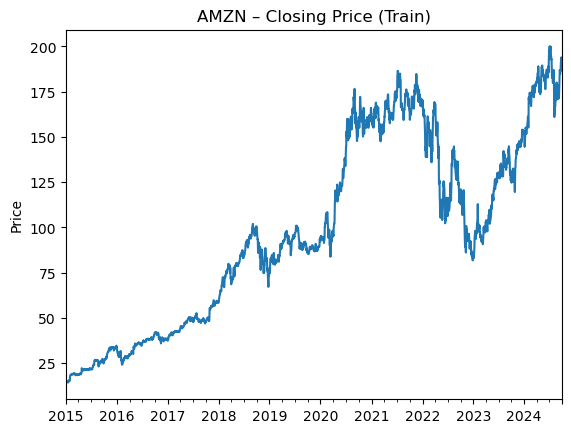

Missing values: 0


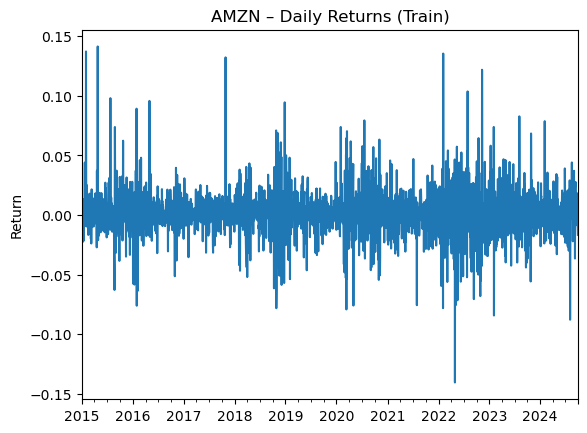

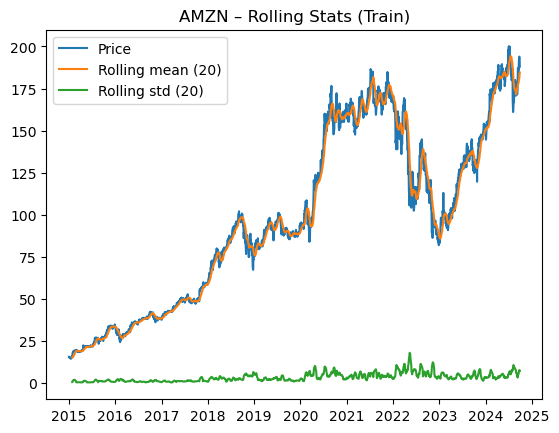

ADF Test – AMZN price
  Test statistic: -0.8912
  p-value      : 0.7909
  → Fail to reject H0: The seiries is NON-stationary process.

First differenced time series: 

ADF Test – AMZN price
  Test statistic: -17.0864
  p-value      : 0.0000
  → Reject H0: The series is stationary process.



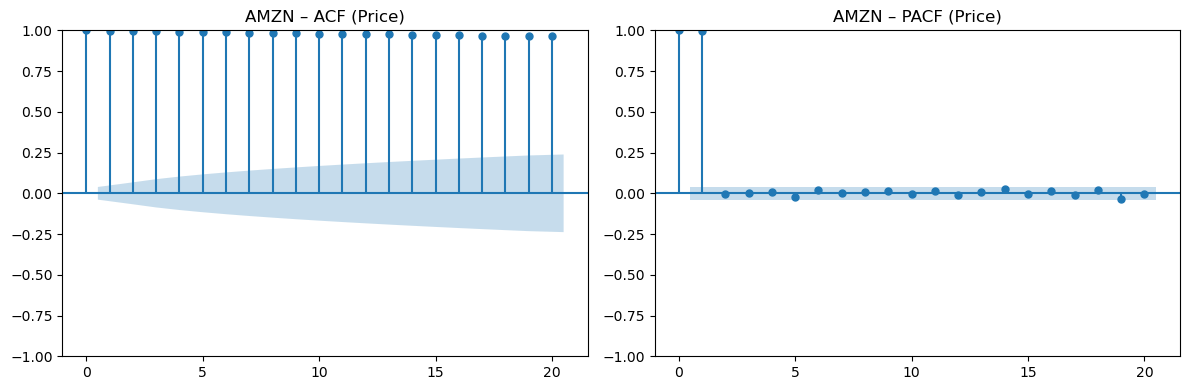

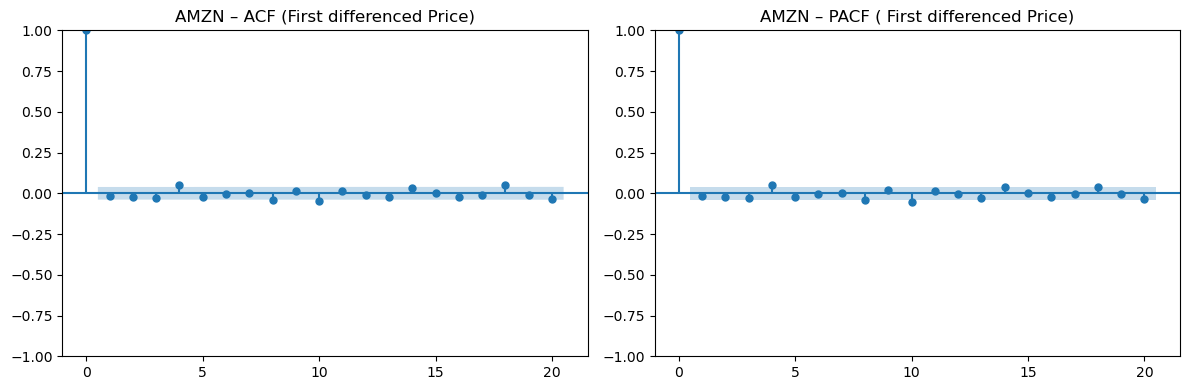

In [18]:
eda_single_asset("AMZN", prices_train)


===== EDA for NVDA =====



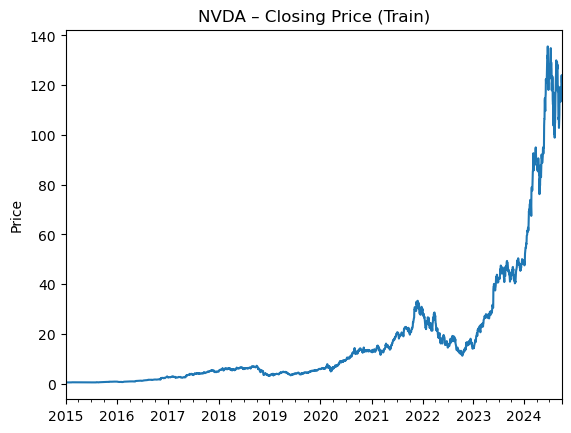

Missing values: 0


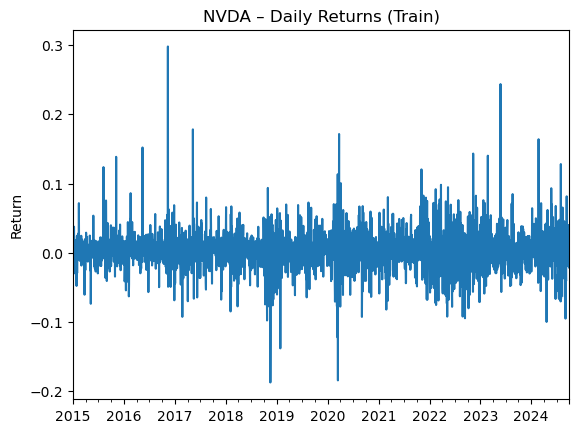

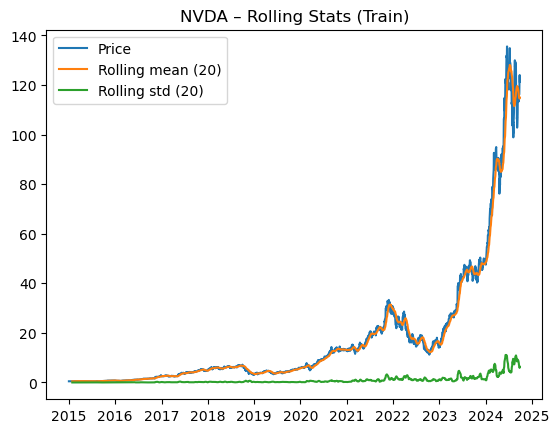

ADF Test – NVDA price
  Test statistic: 2.6734
  p-value      : 0.9991
  → Fail to reject H0: The seiries is NON-stationary process.

First differenced time series: 

ADF Test – NVDA price
  Test statistic: -9.0598
  p-value      : 0.0000
  → Reject H0: The series is stationary process.



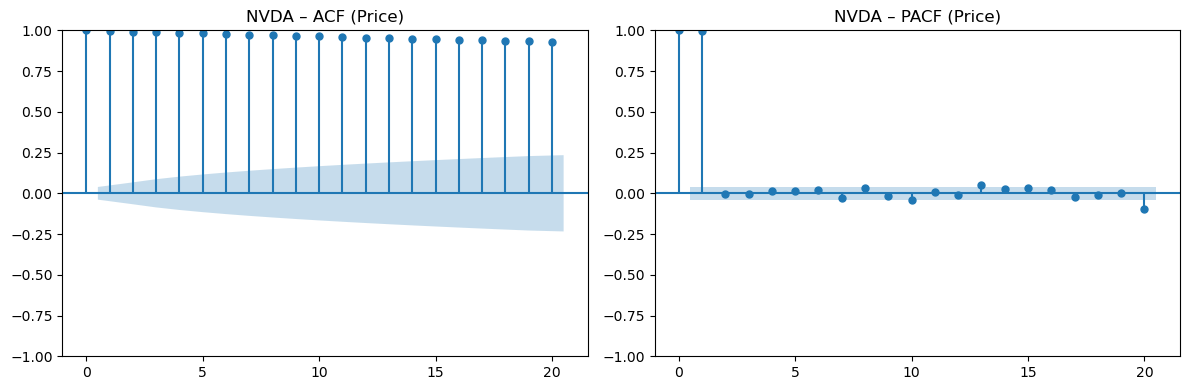

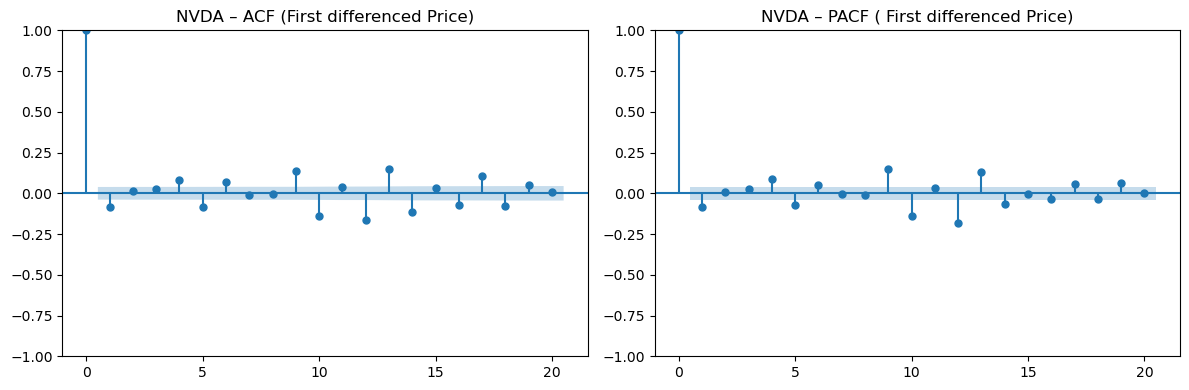

In [19]:
eda_single_asset("NVDA", prices_train)


===== EDA for TLT =====



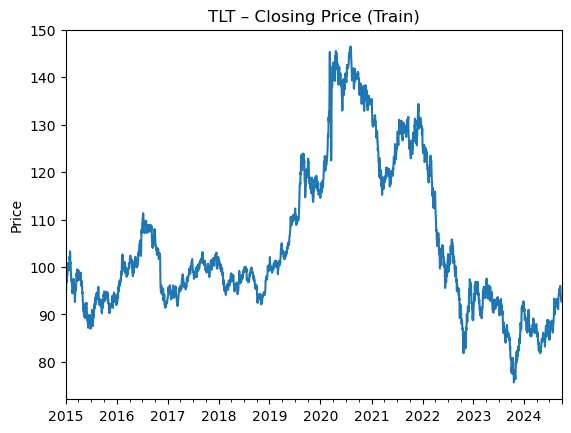

Missing values: 0


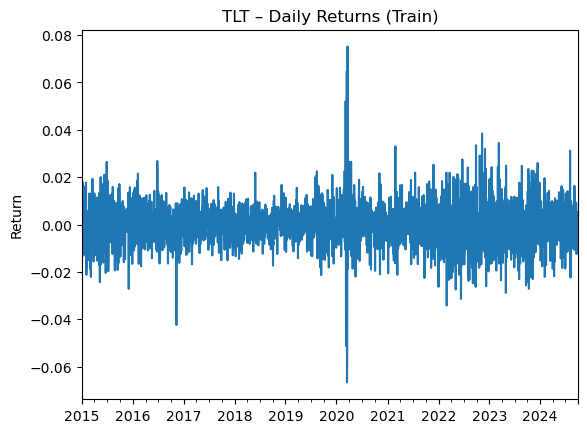

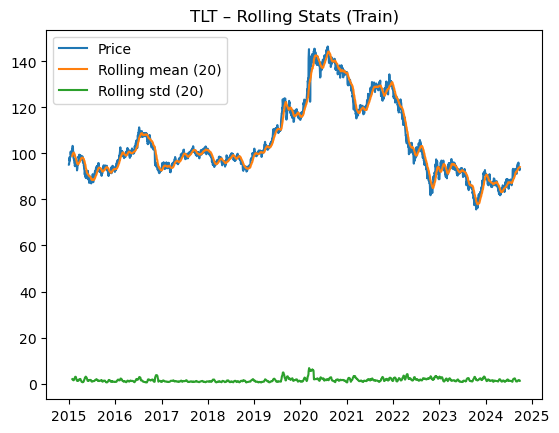

ADF Test – TLT price
  Test statistic: -1.4821
  p-value      : 0.5424
  → Fail to reject H0: The seiries is NON-stationary process.

First differenced time series: 

ADF Test – TLT price
  Test statistic: -9.5343
  p-value      : 0.0000
  → Reject H0: The series is stationary process.



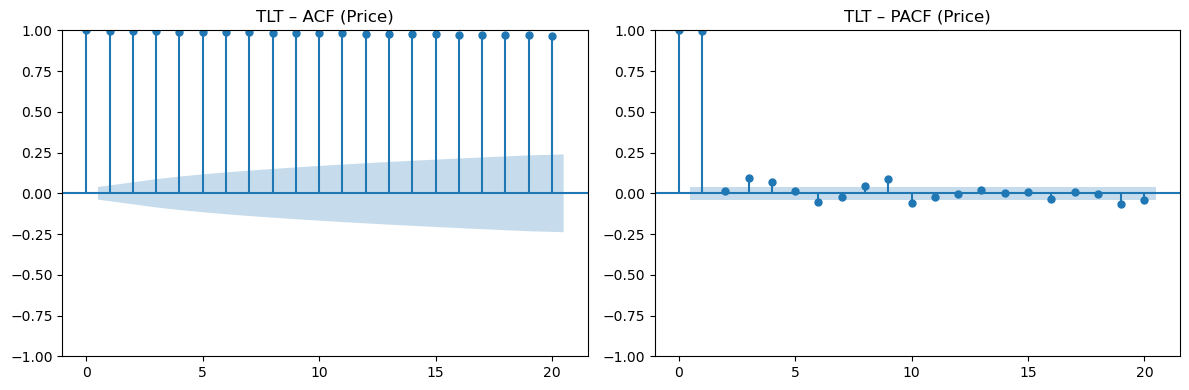

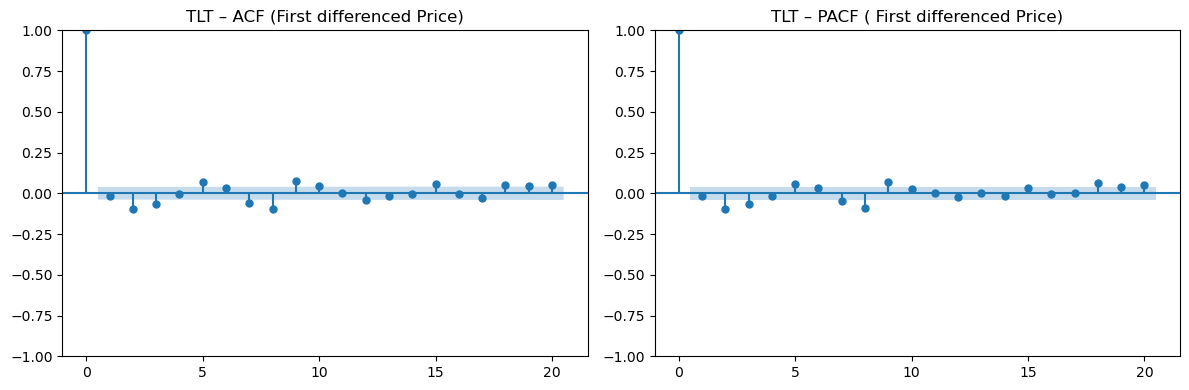

In [20]:
eda_single_asset("TLT", prices_train)


===== EDA for QQQ =====



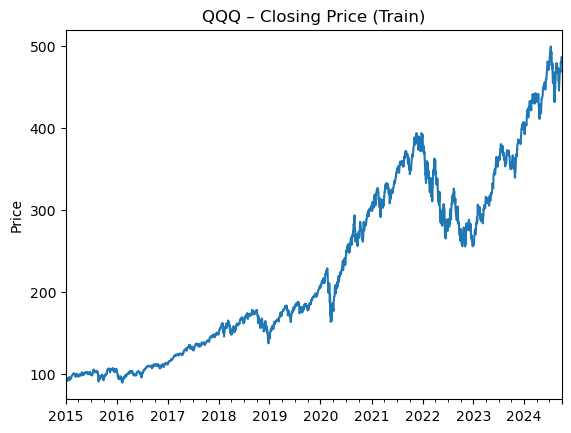

Missing values: 0


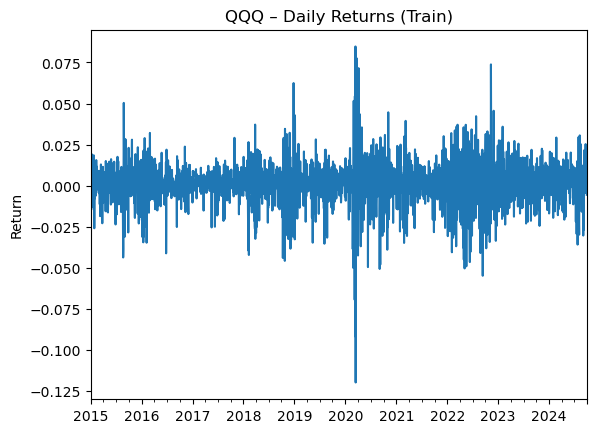

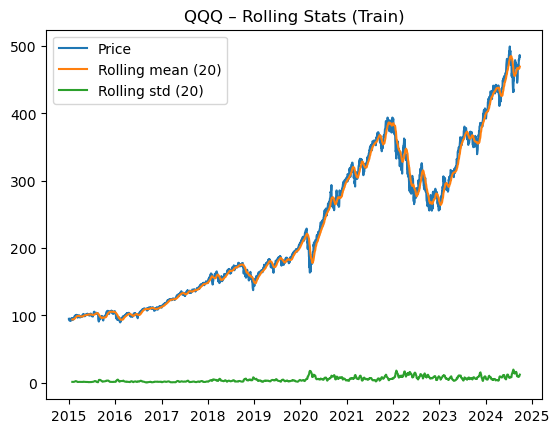

ADF Test – QQQ price
  Test statistic: 0.6893
  p-value      : 0.9896
  → Fail to reject H0: The seiries is NON-stationary process.

First differenced time series: 

ADF Test – QQQ price
  Test statistic: -13.5078
  p-value      : 0.0000
  → Reject H0: The series is stationary process.



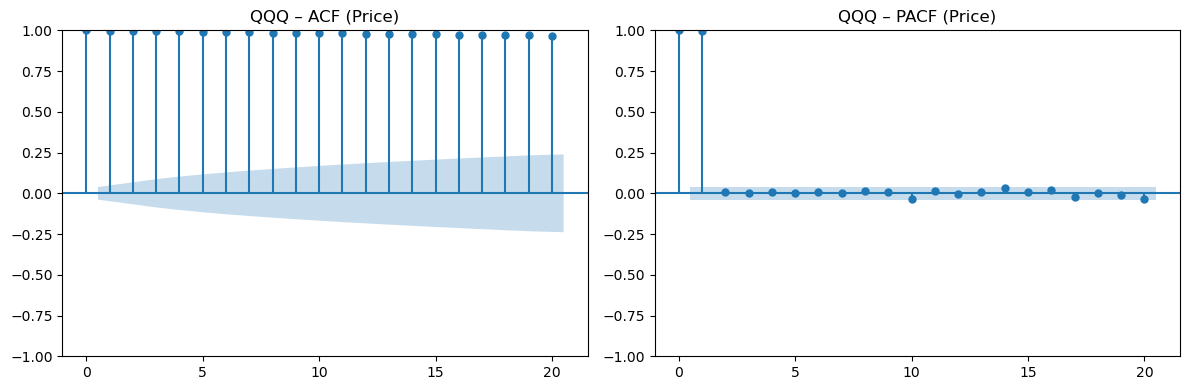

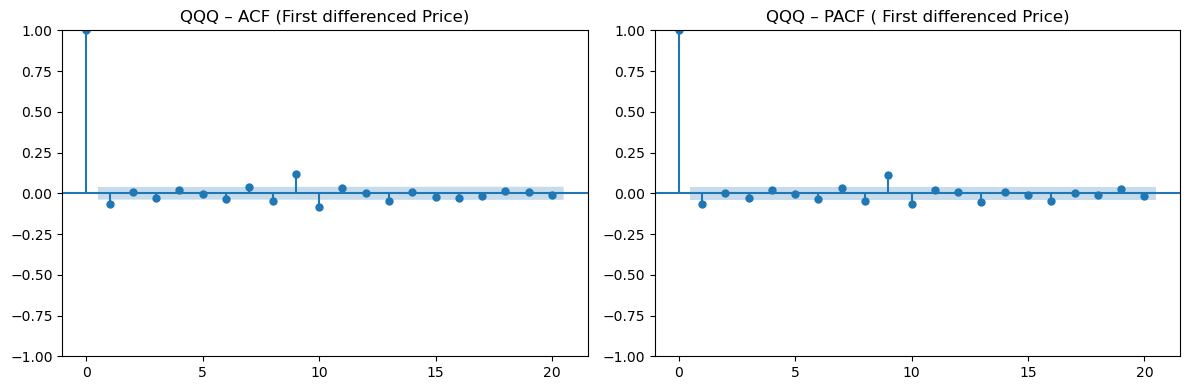

In [21]:
eda_single_asset("QQQ", prices_train)


===== EDA for BTC-USD =====



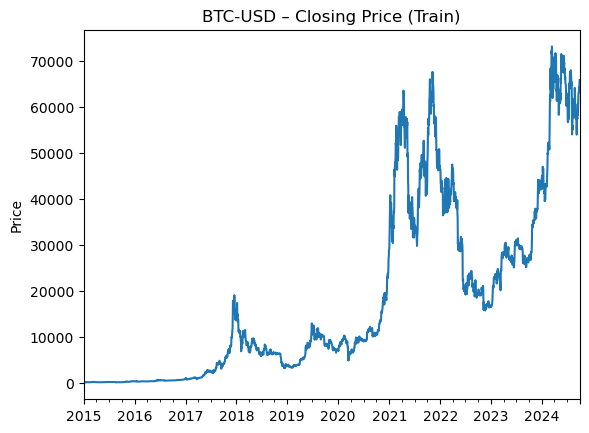

Missing values: 0


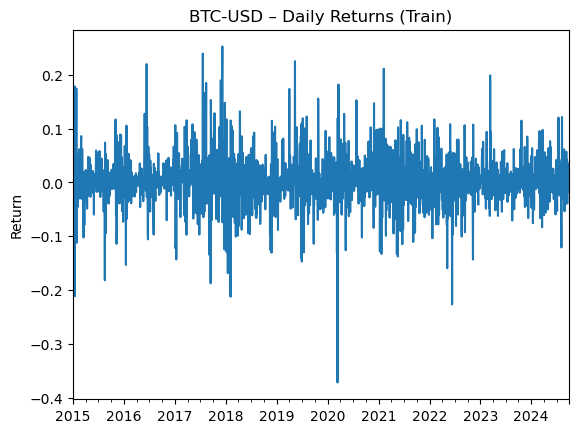

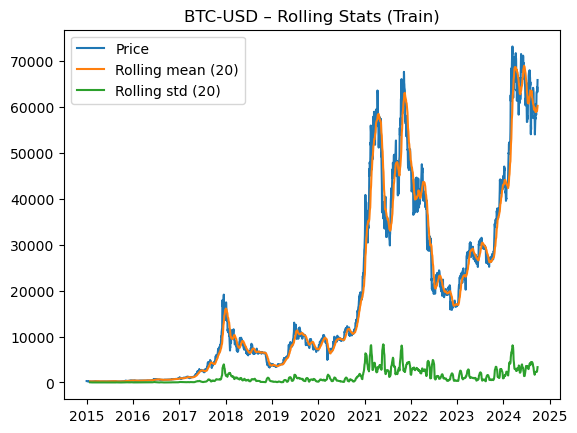

ADF Test – BTC-USD price
  Test statistic: -0.6710
  p-value      : 0.8541
  → Fail to reject H0: The seiries is NON-stationary process.

First differenced time series: 

ADF Test – BTC-USD price
  Test statistic: -8.5313
  p-value      : 0.0000
  → Reject H0: The series is stationary process.



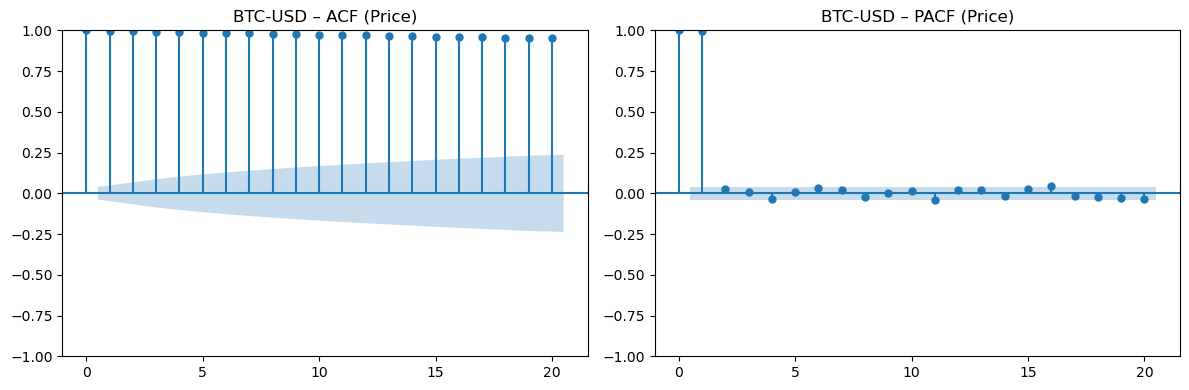

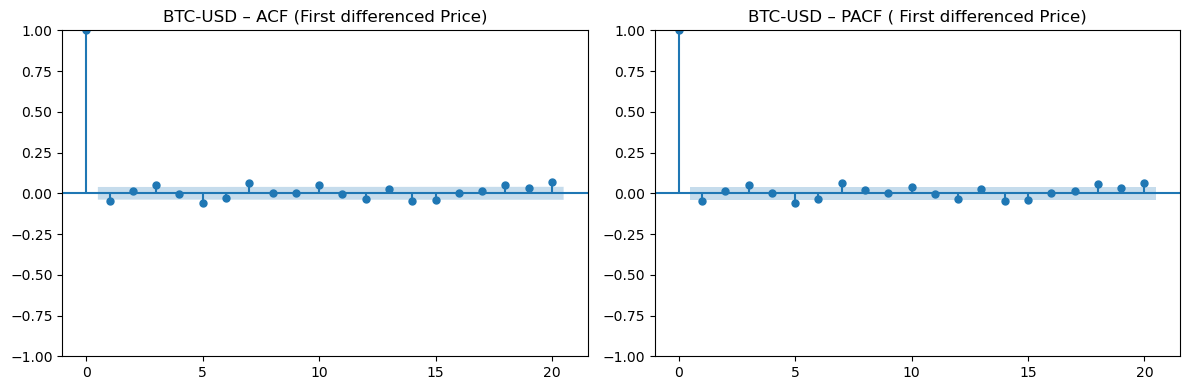

In [22]:
eda_single_asset("BTC-USD", prices_train)

## 6. Transform & Naive Forecast Helpers

This section defines various forecasting methods to establish baseline models:

**Baseline Methods:**
- **naive_mean_forecast()**: Predicts future values as the mean of historical data
- **naive_last_forecast()**: Uses the last observed value for all future predictions
- **drift_forecast()**: Random walk with drift model, extending the historical trend linearly

**Advanced Methods:**
- **ets_forecast()**: Exponential Smoothing (ETS) with additive trend, capturing level and trend components
- **arima_forecast()**: ARIMA(p,d,q) model for more sophisticated time series prediction

These methods provide a range of forecasting approaches from simple baselines to more complex statistical models, allowing us to compare performance and select the best approach for each asset.

In [23]:
from statsmodels.tsa.arima.model import ARIMA
def difference_series(series: pd.Series, order: int = 1) -> pd.Series:
    return series.diff(order)


def naive_mean_forecast(train_series: pd.Series, horizon: int) -> np.ndarray:
    mean_val = train_series.mean()
    return np.full(horizon, mean_val) # this line creates a numpy arr filled with the same value.


def naive_last_forecast(train_series: pd.Series, horizon: int) -> np.ndarray:
    last_val = train_series.iloc[-1]
    return np.full(horizon, last_val)


def drift_forecast(train_series: pd.Series, horizon: int) -> np.ndarray:
    """
    Random-walk-with-drift style forecast (same idea as in your book).
    """
    y0 = train_series.iloc[0]
    y_last = train_series.iloc[-1]
    n = len(train_series)
    delta_X = (n-1)
    delta_Y = (y_last - y0)
    if n <= 1:
        return naive_last_forecast(train_series, horizon)

    drift = delta_Y / delta_X
    t = np.arange(n, n + horizon)
    return y0 + drift * t

# Exponential Smoothing (ETS) and ARIMA model

def ets_forecast(train_series: pd.Series, horizon: int) -> np.ndarray:
    """
    Additive trend ETS model (no seasonality).
    """
    model = ExponentialSmoothing(
        train_series,
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    )
    fit = model.fit(optimized=True)
    return fit.forecast(horizon)  # returns a numpy array


def arima_forecast(train_series: pd.Series, horizon: int,
                   order=(1, 1, 1)) -> np.ndarray:
    """
    Simple ARIMA(p,d,q) forecast. Defaults to ARIMA(1,1,1).
    """
    model = ARIMA(train_series, order=order)
    fit = model.fit()
    return fit.forecast(horizon)

## 7. Evaluate Model Asset Helpers

This section implements comprehensive model evaluation functionality:

**Main Function: evaluate_asset_models()**
- Applies all forecasting methods (mean, last, drift, ETS, ARIMA) to each asset
- Computes RMSE (Root Mean Squared Error) for each method to measure prediction accuracy
- Automatically selects the best performing model based on lowest RMSE
- Creates detailed visualizations comparing actual vs predicted prices for all methods
- Highlights the best model in the visualization for easy identification

**Visualization Function: visualise_diff_rmse()**
- Generates bar charts comparing RMSE values across different forecasting methods
- Identifies and displays the best performing model for each asset
- Provides clear visual comparison of model performance

These functions are then applied to each asset (AMZN, NVDA, TLT, QQQ, BTC-USD) individually to determine the optimal forecasting approach for each security.

In [24]:
from typing import Dict

def evaluate_asset_models(symbol: str, train_df: pd.DataFrame, test_df: pd.DataFrame):
    y_train = train_df[symbol].dropna()
    y_test = test_df[symbol].dropna()
    horizon = len(y_test)

    print(f"\n===== {symbol} – Modeling on Price =====")
    print("Train length:", len(y_train), "Test length:", len(y_test))

    idx = y_test.index

    # --- Baseline/naive forecasts ---
    preds_mean  = pd.Series(naive_mean_forecast(y_train, horizon), index=idx)
    preds_last  = pd.Series(naive_last_forecast(y_train, horizon), index=idx)
    preds_drift = pd.Series(drift_forecast(y_train, horizon),      index=idx)

    # --- ETS forecast ---
    try:
        preds_ets = pd.Series(ets_forecast(y_train, horizon), index=idx)
        #print(preds_ets)
    except Exception as e:
        print(f"[{symbol}] ETS failed: {e}")
        preds_ets = None

    # --- Optional: ARIMA forecast ---
    try:
        preds_arima = pd.Series(arima_forecast(y_train, horizon, order=(1,1,1)), index=idx)
    except Exception as e:
        print(f"[{symbol}] ARIMA failed: {e}")
        preds_arima = None

    # --- Compute RMSEs ---
    def rmse(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

    rmse_mean  = rmse(y_test, preds_mean)
    rmse_last  = rmse(y_test, preds_last)
    rmse_drift = rmse(y_test, preds_drift)

    rmse_dict = {
        "mean":  (rmse_mean,  preds_mean),
        "last":  (rmse_last,  preds_last),
        "drift": (rmse_drift, preds_drift),
    }

    if preds_ets is not None:
        preds_ets = preds_ets.ffill().bfill()  # Fill NaN values using forward fill first, then backward fill
        rmse_ets = rmse(y_test, preds_ets)
        rmse_dict["ets"] = (rmse_ets, preds_ets)
    else:
        rmse_ets = np.nan

    if preds_arima is not None:
        preds_arima = preds_arima.ffill().bfill()  # Fill NaN values using forward fill first, then backward fill
        rmse_arima = rmse(y_test, preds_arima)
        rmse_dict["arima"] = (rmse_arima, preds_arima)
    else:
        rmse_arima = np.nan

    # --- Pick best model based on lowest RMSE ---
    best_name = min(rmse_dict, key=lambda k: rmse_dict[k][0])
    best_rmse, best_pred = rmse_dict[best_name]

    print(f"RMSE (mean):  {rmse_mean:.4f}")
    print(f"RMSE (last):  {rmse_last:.4f}")
    print(f"RMSE (drift): {rmse_drift:.4f}")
    if preds_ets is not None:
        print(f"RMSE (ETS):   {rmse_ets:.4f}")
    if preds_arima is not None:
        print(f"RMSE (ARIMA): {rmse_arima:.4f}")
    print(f"➡ Best model for {symbol}: {best_name} (RMSE={best_rmse:.4f})")

    # Create improved visualization
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot training data with transparency
    ax.plot(train_df[symbol], label="Train", alpha=0.5, linewidth=1.5, color='gray')
    
    # Plot test data (actual)
    ax.plot(test_df[symbol], label="Test (Actual)", linewidth=2.5, color='blue')
    
    # Plot predictions with distinct styles
    ax.plot(preds_mean, color="purple", linestyle='--', marker="o", markersize=4, 
            label="Naive mean", alpha=0.7, linewidth=1.5)
    ax.plot(preds_last, color="orange", linestyle='--', marker="s", markersize=4, 
            label="Naive last", alpha=0.7, linewidth=1.5)
    ax.plot(preds_drift, color="red", linestyle='--', marker="^", markersize=4, 
            label="Drift", alpha=0.7, linewidth=1.5)
    ax.plot(best_pred, color="green", linestyle='-', marker="D", markersize=5, 
            label=f"Best: {best_name.upper()}", linewidth=2.5, alpha=0.9)

    # Zoom to show test period and some context
    months = pd.date_range("2024-01-01", "2025-01-01", freq="MS")
    ax.set_xlim(months[0], months[-1])
    ax.set_xticks(months)
    
    # Add vertical line to separate train/test
    ax.axvline(x=test_df.index[0], color='black', linestyle=':', linewidth=2, alpha=0.5)
    
    # Formatting
    ax.set_title(f"{symbol} - Price Forecast Comparison", fontsize=14, fontweight='bold')
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Price ($)", fontsize=12)
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

    return {
        "rmse_mean":  rmse_mean,
        "rmse_last":  rmse_last,
        "rmse_drift": rmse_drift,
        "rmse_ets":   rmse_ets,
        "rmse_arima": rmse_arima,
        "pred_mean":  preds_mean,
        "pred_last":  preds_last,
        "pred_drift": preds_drift,
        "pred_ets":   preds_ets,
        "pred_arima": preds_arima,
        # Best choice:
        "best_name":  best_name,
        "pred_best":  best_pred,
        "rmse_best":  best_rmse,
    }


In [25]:
def visualise_diff_rmse(rmse_result: dict, asset_name: str):
    RMSE_df = pd.DataFrame({
    "RMSE TYPE": ["rmse_mean", "rmse_last", "rmse_ets", "rmse_arima", "rmse_drift"],
    "RMSE VALUE": [rmse_result["rmse_mean"], rmse_result["rmse_last"], rmse_result["rmse_ets"], rmse_result["rmse_arima"], rmse_result["rmse_drift"]]
})
    RMSE_df.sort_values(by="RMSE VALUE", ascending=False, inplace=True)

    plt.figure(figsize=(10, 6))
    plt.bar(RMSE_df["RMSE TYPE"], RMSE_df["RMSE VALUE"], color='steelblue', edgecolor='black', alpha=0.7)
    plt.xlabel("Model Type", fontsize=12, fontweight='bold')
    plt.ylabel("RMSE Value", fontsize=12, fontweight='bold')
    plt.title(f"RMSE Comparison for {asset_name} - Different Forecasting Models", fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

    print(f"For the asset {asset_name}, {RMSE_df.iloc[-1][0].removeprefix("rmse_")} is the best model.")

    return RMSE_df




===== AMZN – Modeling on Price =====
Train length: 2542 Test length: 44
RMSE (mean):  97.3332
RMSE (last):  12.1393
RMSE (drift): 10.6686
RMSE (ETS):   10.6016
RMSE (ARIMA): 12.4113
➡ Best model for AMZN: ets (RMSE=10.6016)


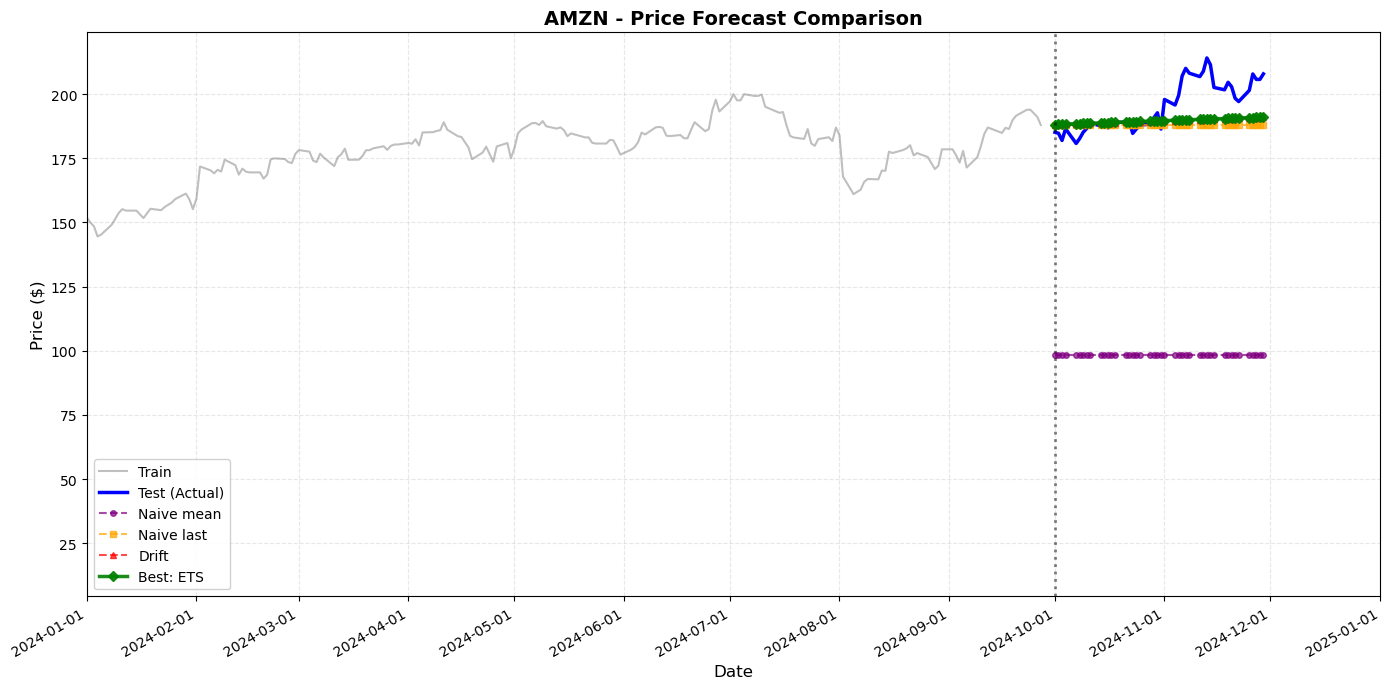

In [26]:
amzn_results = evaluate_asset_models("AMZN", prices_train, prices_test)


#print(amzn_results)

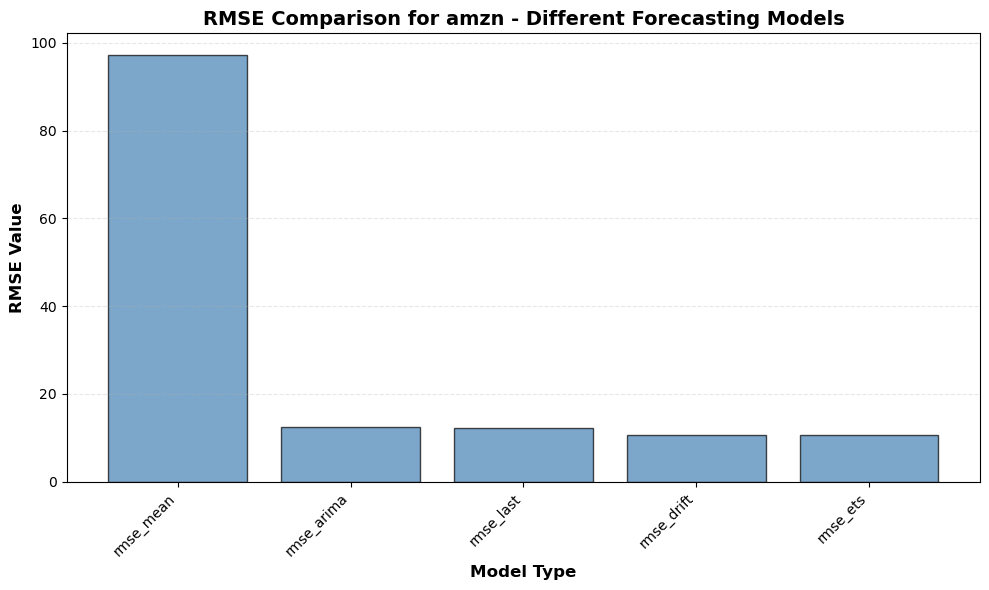

For the asset amzn, ets is the best model.


,RMSE TYPE,RMSE VALUE
0,rmse_mean,97.333188
3,rmse_arima,12.411340
1,rmse_last,12.139309
4,rmse_drift,10.668629
2,rmse_ets,10.601566


In [27]:
visualise_diff_rmse(amzn_results, "amzn")


===== NVDA – Modeling on Price =====
Train length: 2542 Test length: 44
RMSE (mean):  120.5458
RMSE (last):  18.2448
RMSE (drift): 17.1185
RMSE (ETS):   13.2844
RMSE (ARIMA): 18.0672
➡ Best model for NVDA: ets (RMSE=13.2844)


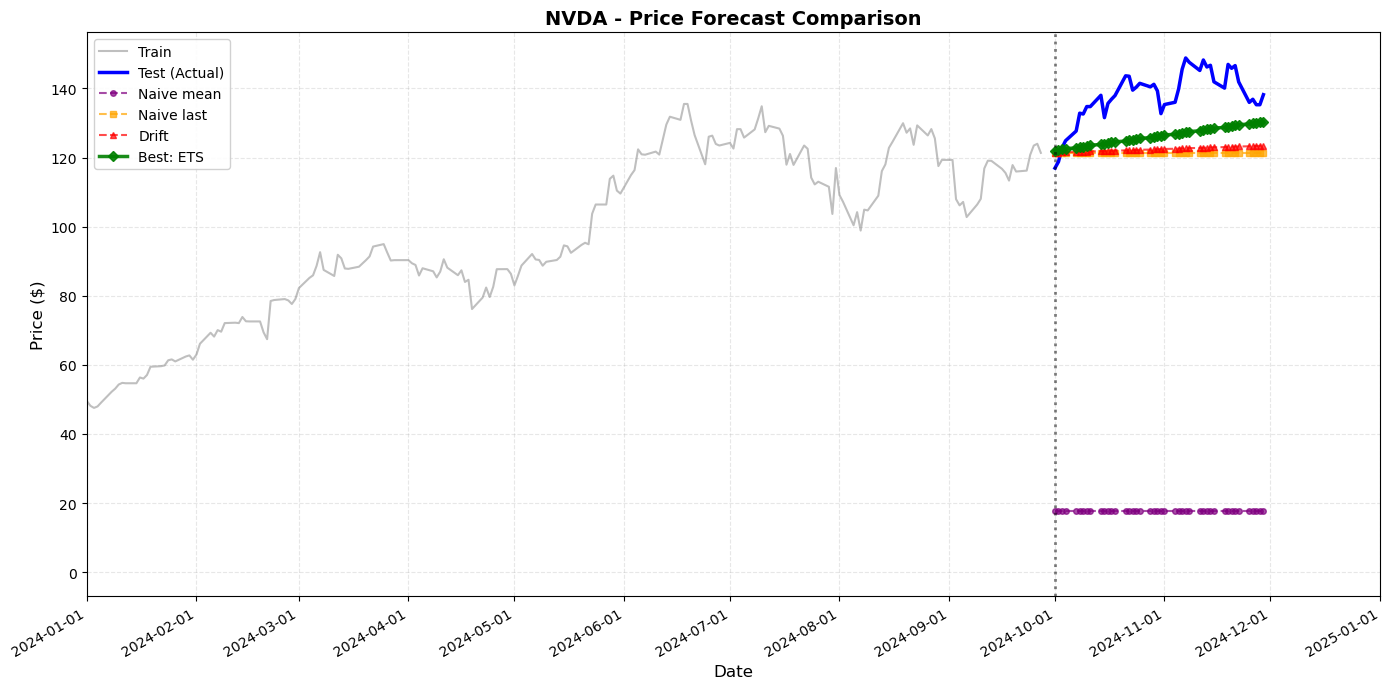

In [28]:
nvda_results =  evaluate_asset_models("NVDA", prices_train, prices_test)

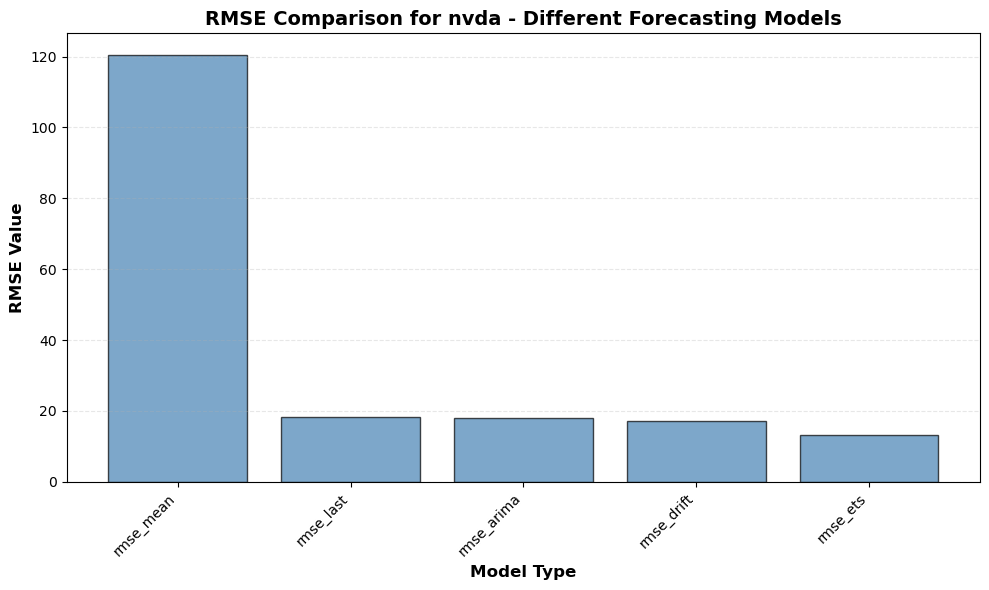

For the asset nvda, ets is the best model.


,RMSE TYPE,RMSE VALUE
0,rmse_mean,120.545847
1,rmse_last,18.244760
3,rmse_arima,18.067211
4,rmse_drift,17.118532
2,rmse_ets,13.284436


In [29]:
visualise_diff_rmse(nvda_results, "nvda")


===== TLT – Modeling on Price =====
Train length: 2542 Test length: 44
RMSE (mean):  16.4330
RMSE (last):  5.3915
RMSE (drift): 5.3753
RMSE (ETS):   5.3654
RMSE (ARIMA): 5.3914
➡ Best model for TLT: ets (RMSE=5.3654)


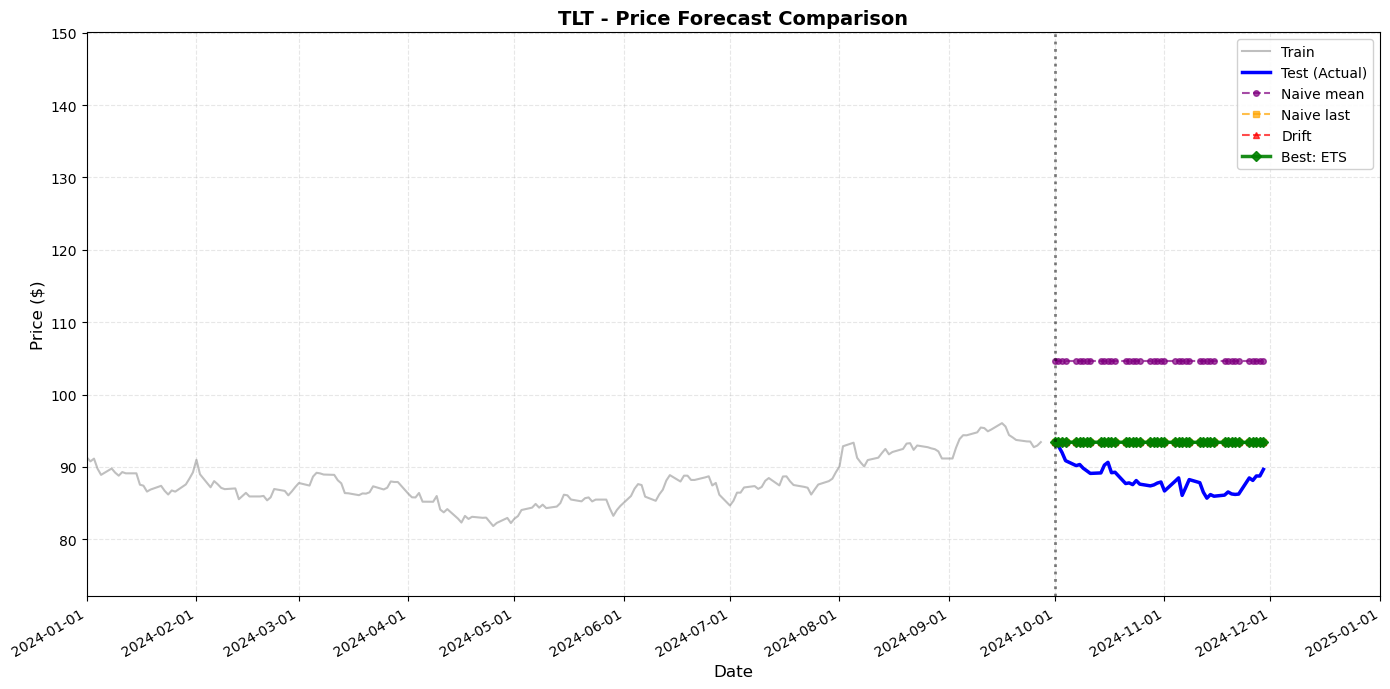

In [30]:
tlt_results =  evaluate_asset_models("TLT", prices_train, prices_test)

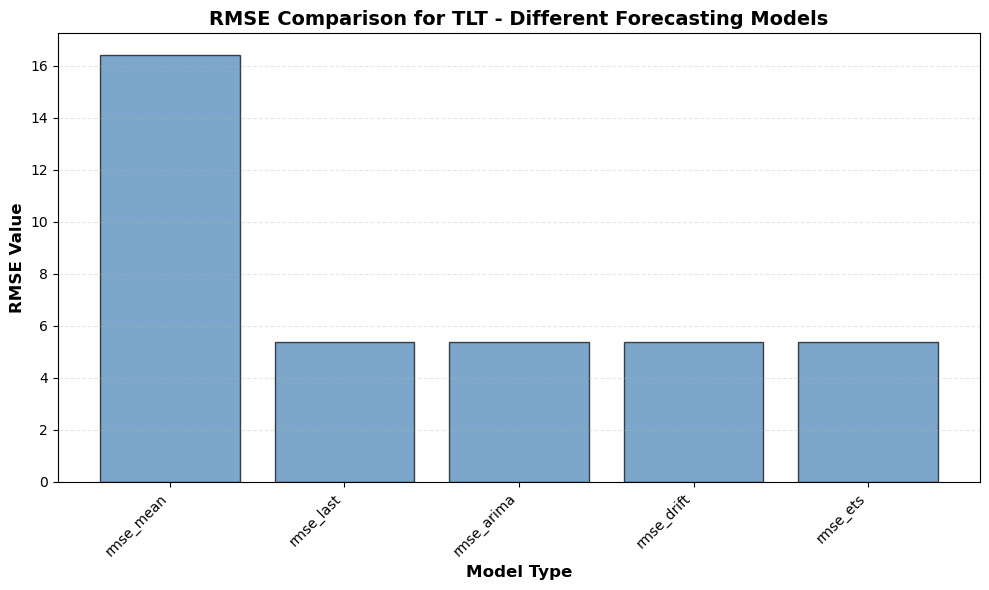

For the asset TLT, ets is the best model.


,RMSE TYPE,RMSE VALUE
0,rmse_mean,16.432954
1,rmse_last,5.391469
3,rmse_arima,5.391351
4,rmse_drift,5.375278
2,rmse_ets,5.365350


In [31]:
visualise_diff_rmse(tlt_results, "TLT")


===== QQQ – Modeling on Price =====
Train length: 2542 Test length: 44
RMSE (mean):  264.8388
RMSE (last):  14.3181
RMSE (drift): 10.8844
RMSE (ETS):   10.6412
RMSE (ARIMA): 14.1967
➡ Best model for QQQ: ets (RMSE=10.6412)


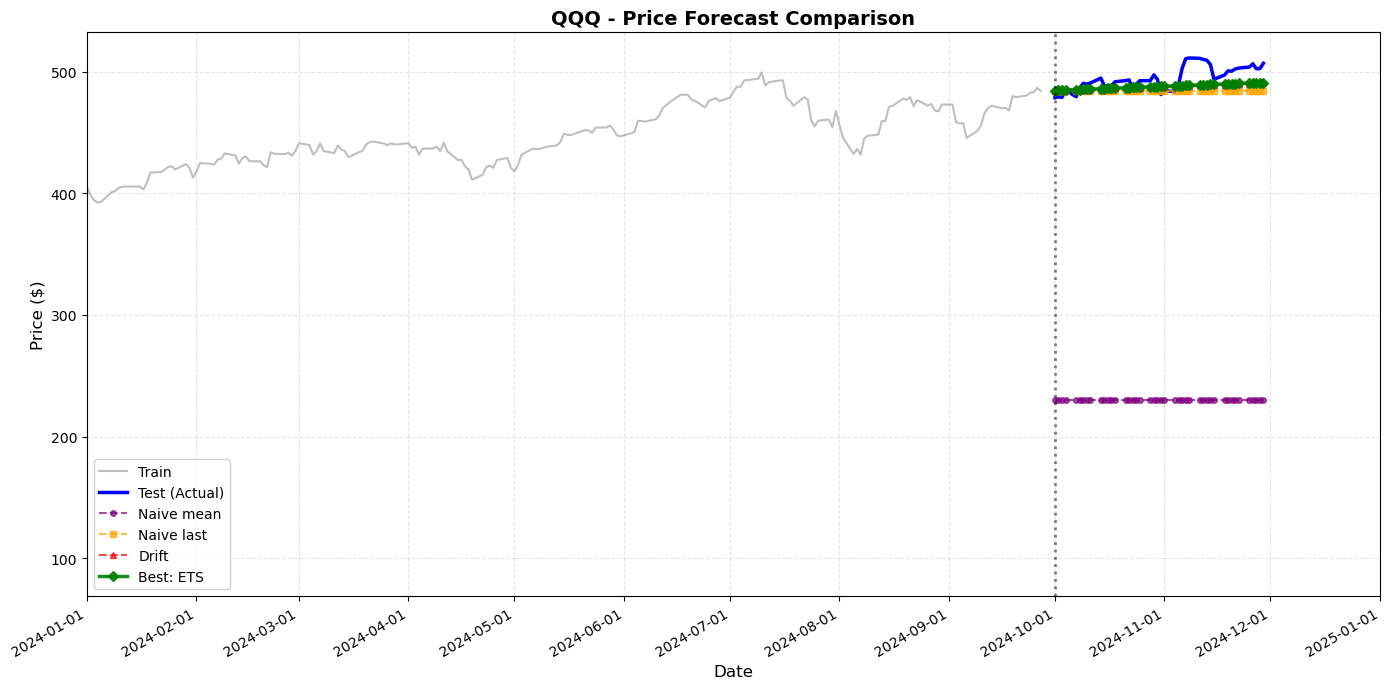

In [32]:
qqq_results =  evaluate_asset_models("QQQ", prices_train, prices_test)

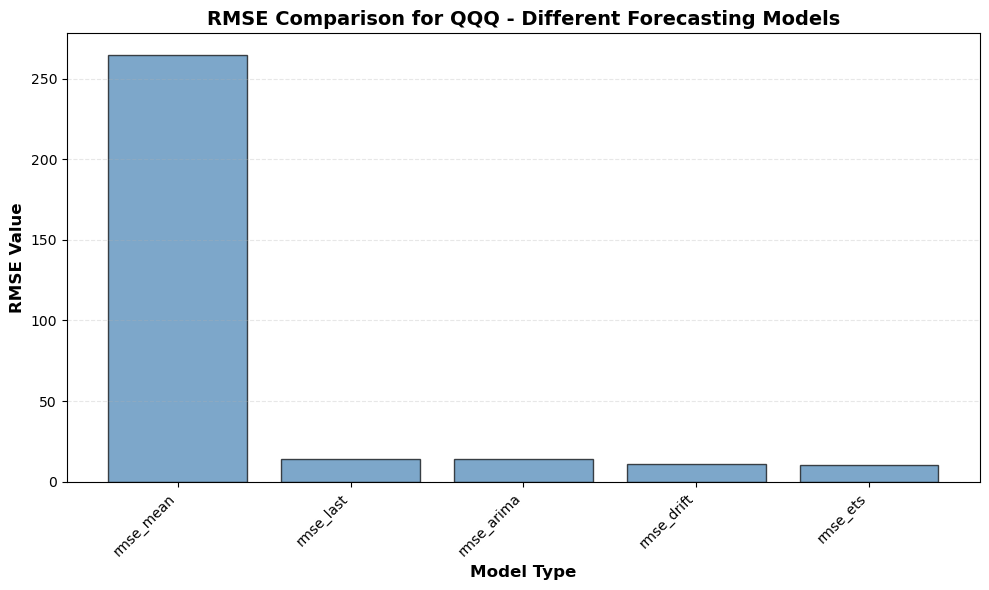

For the asset QQQ, ets is the best model.


,RMSE TYPE,RMSE VALUE
0,rmse_mean,264.838842
1,rmse_last,14.318077
3,rmse_arima,14.196678
4,rmse_drift,10.884362
2,rmse_ets,10.641153


In [33]:
visualise_diff_rmse(qqq_results, "QQQ")


===== BTC-USD – Modeling on Price =====
Train length: 2542 Test length: 44
RMSE (mean):  58855.7535
RMSE (last):  16485.0076
RMSE (drift): 15889.1238
RMSE (ETS):   16573.0293
RMSE (ARIMA): 16494.7488
➡ Best model for BTC-USD: drift (RMSE=15889.1238)


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


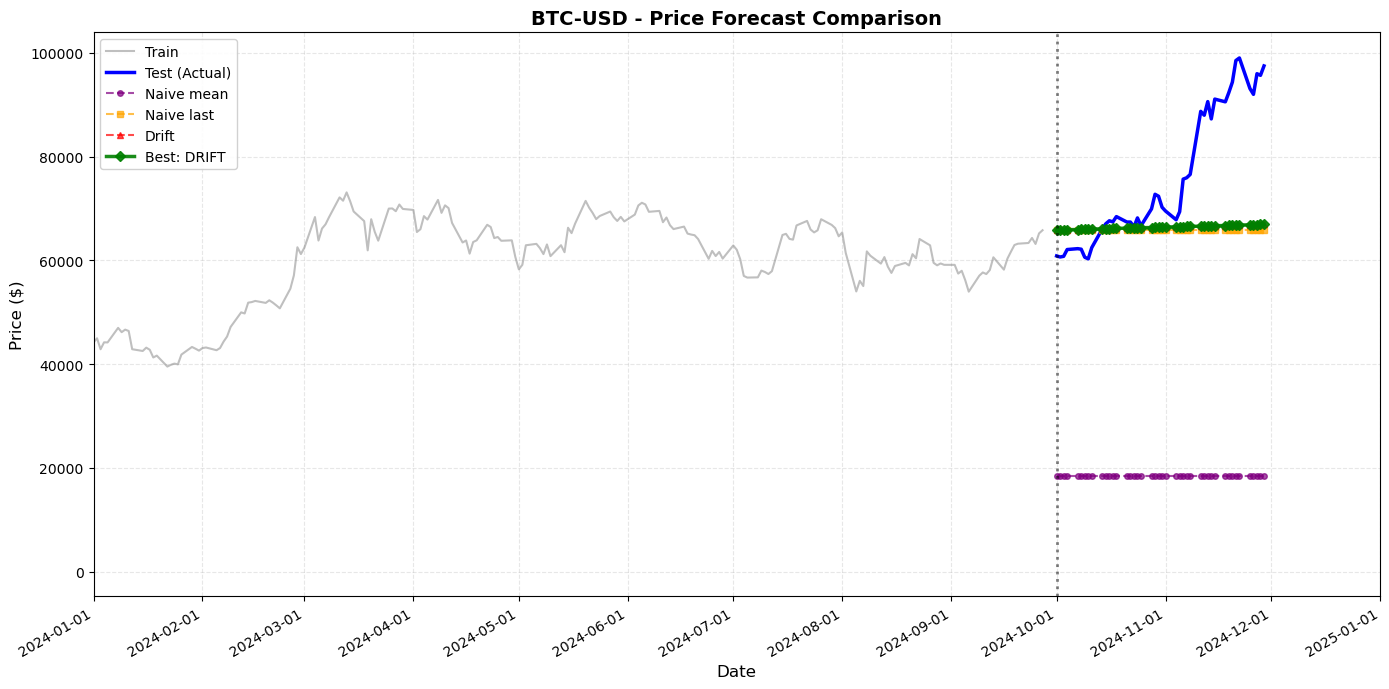

In [34]:
btc_usd_results =  evaluate_asset_models("BTC-USD", prices_train, prices_test)

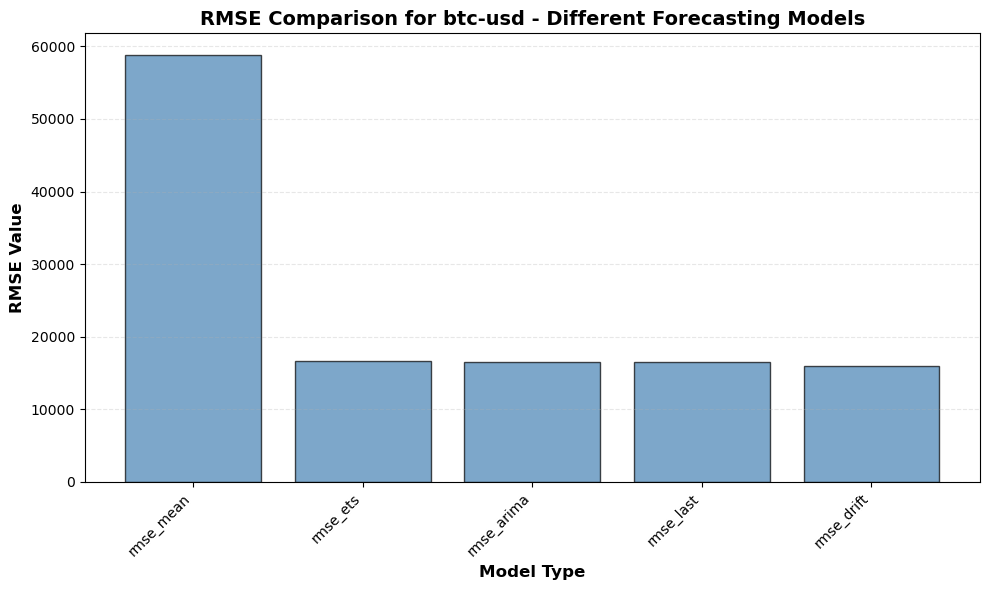

For the asset btc-usd, drift is the best model.


,RMSE TYPE,RMSE VALUE
0,rmse_mean,"58,855.753503"
2,rmse_ets,"16,573.029349"
3,rmse_arima,"16,494.748764"
1,rmse_last,"16,485.007626"
4,rmse_drift,"15,889.123759"


In [35]:
visualise_diff_rmse(btc_usd_results, "btc-usd")

## 8. Portfolio Level Forecast

This section aggregates individual asset forecasts into a comprehensive portfolio forecast:

**Function: build_portfolio_forecast_normalised()**
- Takes the best forecast for each asset and combines them using portfolio weights
- Normalizes all prices to 1 at the start of the test period to create growth indices
- This normalization ensures fair comparison by measuring relative growth rather than absolute prices
- Applies portfolio weights to normalized indices and sums to get portfolio value
- Computes portfolio-level RMSE to measure overall prediction accuracy
- Visualizes actual vs predicted portfolio performance over the test period

The normalization approach allows us to:
- Compare assets with different price scales fairly
- Focus on percentage returns rather than dollar amounts
- Properly weight each asset's contribution to portfolio performance

This gives us a single portfolio-level forecast that incorporates predictions from all individual assets.

In [36]:
from typing import Dict

def build_portfolio_forecast_normalised(
    asset_forecasts: Dict[str, pd.Series],
    test_prices: pd.DataFrame,
    weights: pd.Series,
):
    """
    Combine single-asset forecasts into a *proper* weighted portfolio forecast.

    - Normalize each asset's price and forecast to 1 at the start of the test period,
      so they represent growth indices.
    - Then apply the portfolio weights to those growth indices.
    """
    # Make a prediction DataFrame aligned to the test index
    df_pred = pd.DataFrame({sym: asset_forecasts[sym] for sym in asset_forecasts})
    df_pred = df_pred.reindex(test_prices.index)

    # Use only the symbols we have weights for
    symbols = list(weights.index)
    test_sub = test_prices[symbols].loc[df_pred.index]

    # Drop any days where we don't have predictions for all assets
    valid_idx = df_pred.dropna(axis=0, how="any").index
    test_sub = test_sub.loc[valid_idx]
    df_pred = df_pred.loc[valid_idx]

    # --- Normalize to 1 at the start of the test period ---
    # Actual prices
    actual_norm = test_sub / test_sub.iloc[0]

    # Predicted prices
    pred_norm = df_pred / df_pred.iloc[0]

    # --- Build portfolio series from normalized paths ---
    portfolio_actual = (actual_norm * weights).sum(axis=1)
    portfolio_pred   = (pred_norm   * weights).sum(axis=1)

    # Compute a simple RMSE at the portfolio level
    rmse_portfolio = np.sqrt(((portfolio_actual - portfolio_pred) ** 2).mean())
    print(f"Portfolio RMSE (normalized index space): {rmse_portfolio:.4f}")

    plt.plot(portfolio_actual.index, portfolio_actual, label="Actual portfolio")
    plt.plot(portfolio_pred.index, portfolio_pred, label="Predicted portfolio")
    plt.title("Portfolio – Actual vs Predicted (Test)")
    plt.legend()

    plt.gcf().autofmt_xdate()
    plt.show()

    return portfolio_actual, portfolio_pred, rmse_portfolio


Portfolio RMSE (normalized index space): 0.0970


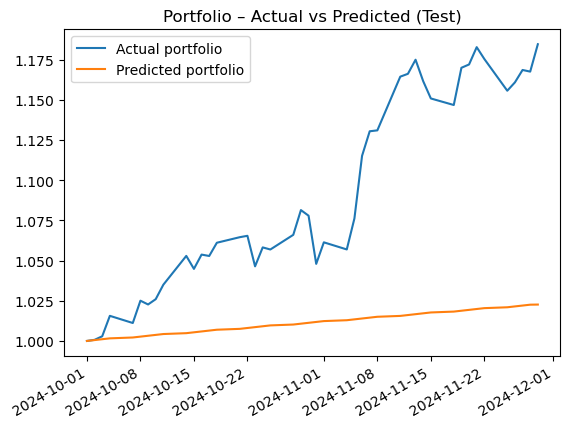

In [37]:
forecasts = {
    "AMZN": amzn_results["pred_best"],
    "NVDA": nvda_results["pred_best"],
    "TLT":  tlt_results["pred_best"],
    "QQQ":  qqq_results["pred_best"],
    "BTC-USD": btc_usd_results["pred_best"],
}

portfolio_actual, portfolio_pred, rmse_port = build_portfolio_forecast_normalised(
    forecasts, prices_test, WEIGHTS
)

In [38]:
portfolio_forecast_df = pd.DataFrame({
    "Porfolio_Actual": portfolio_actual,
    "Portfolio_Predicted": portfolio_pred,
    "Portfolio_RMSE": rmse_port
})

len(portfolio_forecast_df)

44

In [39]:
portfolio_forecast_df.head()

,Porfolio_Actual,Portfolio_Predicted,Portfolio_RMSE
2024-10-01,1.000000,1.000000,0.096956
2024-10-02,1.000688,1.000537,0.096956
2024-10-03,1.002900,1.001074,0.096956
2024-10-04,1.015618,1.001611,0.096956
2024-10-07,1.011161,1.002148,0.096956


## 9. 5% Return Evaluation

This section evaluates whether the portfolio achieves the target return goal:

**Functions:**
- **portfolio_return_from_prices()**: Calculates the total return from start to end of test period
- **evaluate_5pct_goal()**: Compares actual vs predicted returns against the 5% threshold

**Key Outputs:**
- Actual portfolio return achieved during the test period
- Model-predicted return based on forecasts
- Clear indication (✅/❌) of whether the 5% goal is met
- Detailed visualization showing:
  - Actual portfolio performance
  - Predicted portfolio performance
  - 5% return target line for easy comparison
  - Annotated return percentages on the plot

This analysis helps assess:
1. How close the portfolio came to the 5% return goal
2. Whether our forecasting models accurately predicted this outcome
3. The reliability of using these models for forward-looking investment decisions

In [40]:
def portfolio_return_from_prices(price_series: pd.Series) -> float:
    start_val = price_series.iloc[0]
    end_val = price_series.iloc[-1]
    return (end_val / start_val) - 1.0


def evaluate_5pct_goal(portfolio_actual: pd.Series, portfolio_pred: pd.Series):
    actual_ret = portfolio_return_from_prices(portfolio_actual)
    pred_ret = portfolio_return_from_prices(portfolio_pred)

    print(f"Actual portfolio return (test):   {actual_ret*100:.2f}%")
    print(f"Model-implied return (test):      {pred_ret*100:.2f}%")

    if pred_ret >= 0.05:
        print("✅ Model forecasts imply ≥ 5% return in test period.")
    else:
        print("❌ Model forecasts do NOT reach 5% return in test period.")

    return actual_ret, pred_ret

# Example after building portfolio series:
# actual_ret, pred_ret = evaluate_5pct_goal(portfolio_actual, portfolio_pred)


In [41]:
actual_ret, pred_ret = evaluate_5pct_goal(portfolio_actual, portfolio_pred)

Actual portfolio return (test):   18.46%
Model-implied return (test):      2.26%
❌ Model forecasts do NOT reach 5% return in test period.


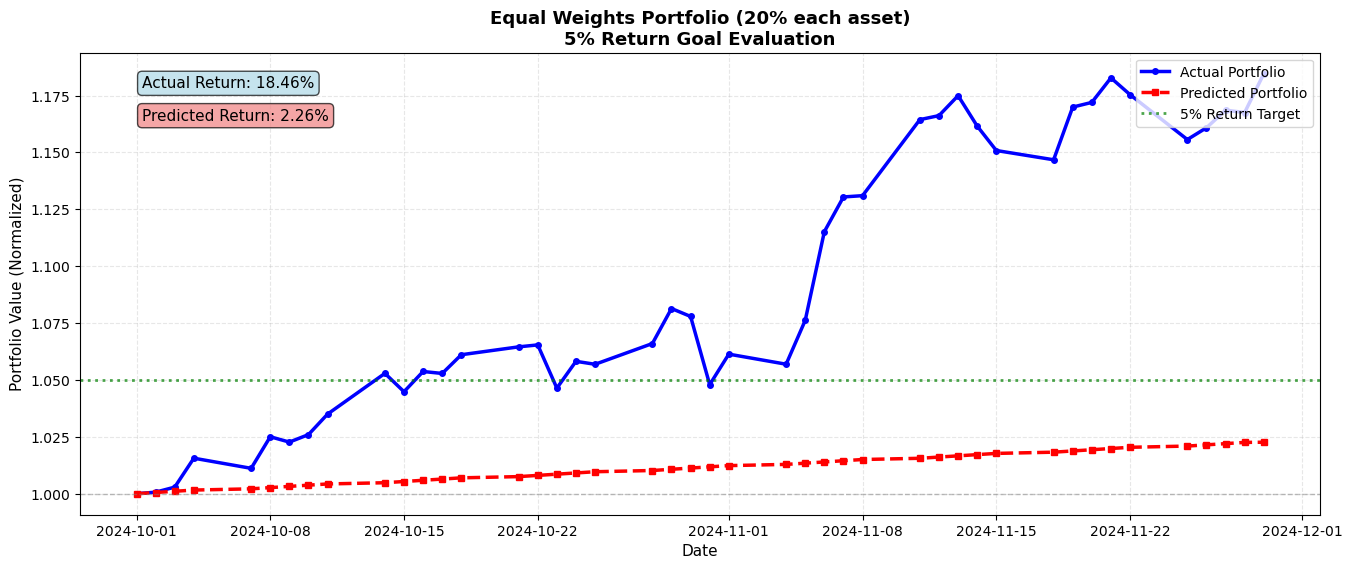

In [42]:
# Create visualization for 5% evaluation results
fig, (ax1) = plt.subplots(figsize=(16, 6))

# Left plot: Equal weights portfolio
ax1.plot(portfolio_actual.index, portfolio_actual, 
         label='Actual Portfolio', linewidth=2.5, color='blue', marker='o', markersize=4)
ax1.plot(portfolio_pred.index, portfolio_pred, 
         label='Predicted Portfolio', linewidth=2.5, color='red', linestyle='--', marker='s', markersize=4)
ax1.axhline(y=1.05, color='green', linestyle=':', linewidth=2, alpha=0.7, label='5% Return Target')
ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add text annotations for returns
ax1.text(0.05, 0.95, f'Actual Return: {actual_ret*100:.2f}%', 
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax1.text(0.05, 0.88, f'Predicted Return: {pred_ret*100:.2f}%', 
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

ax1.set_title('Equal Weights Portfolio (20% each asset)\n5% Return Goal Evaluation', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Portfolio Value (Normalized)', fontsize=11)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

## 10. Adding Brute-Force Search for the Best Weights

This section optimizes portfolio allocation to maximize returns:

**Function: grid_search_weights()**
- Performs exhaustive search over all possible weight combinations (step = 0.1)
- Tests weights from 0% to 100% for each asset in 10% increments
- Ensures weights are long-only (no short selling) and sum to 100%
- Evaluates actual historical performance for each weight combination
- Identifies the optimal weight allocation that maximized returns during the test period

**Key Outputs:**
- Best weight allocation discovered through grid search
- Maximum achievable return with optimized weights
- Comparison of actual vs predicted returns using optimized weights

**Comparative Analysis:**
The section concludes with comprehensive visualizations comparing:
1. **Equal Weights Portfolio** (20% each): Original baseline allocation
2. **Optimized Weights Portfolio**: Best allocation found through grid search
3. Side-by-side comparison showing:
   - How much improvement optimization provides
   - Whether optimized weights help achieve the 5% goal
   - Difference between actual and predicted performance for both strategies

This demonstrates the value of portfolio optimization and whether simple equal weighting or optimized allocation performs better for achieving the investment goals.

In [43]:
import itertools

def total_return_from_index(series: pd.Series) -> float:
    """Total return over the period: (end/start - 1). Assumes series > 0."""
    start = series.iloc[0]
    end   = series.iloc[-1]
    return (end / start) - 1.0


def grid_search_weights(
    assets: list[str],
    test_prices: pd.DataFrame,
    step: float = 0.1,
):
    """
    Brute-force search over all long-only weights with given step that sum to 1.

    Example: step=0.1 with 5 assets => weights in {0,0.1,...,1} s.t. sum=1.
    """
    grid_vals = np.arange(0.0, 1.0 + 1e-9, step)

    # Normalize test prices into growth indices (1 at start) for the assets
    test_sub = test_prices[assets].dropna(how="any")
    test_norm = test_sub / test_sub.iloc[0] # it is a DF where each column is a growth index that starts at 1
    # hence the later values (other than the first values), shows grwoth relative to the first date.
    

    best_ret = -np.inf
    best_w = None
    best_port = None

    for combo in itertools.product(grid_vals, repeat=len(assets)):
        w = np.array(combo)
        if abs(w.sum() - 1.0) > 1e-9:
            continue  # must sum to 1
        if np.allclose(w, 0):
            continue  # skip all-zero

        w_series = pd.Series(w, index=assets)
        port = (test_norm * w_series).sum(axis=1)
        ret = total_return_from_index(port)

        if ret > best_ret:
            best_ret = ret
            best_w = w_series
            best_port = port

    return best_w, best_port, best_ret


In [44]:
best_w, best_port, best_ret = grid_search_weights(TICKERS, prices_test, step=0.1)

print("Best long-only weights (step=0.1):")
print(best_w)
print(f"Best *actual* test-period return: {best_ret*100:.2f}%")


Best long-only weights (step=0.1):
AMZN      0.000000
NVDA      0.000000
TLT       0.000000
QQQ       0.000000
BTC-USD   1.000000
dtype: float64
Best *actual* test-period return: 60.20%


In [45]:
type(best_w)

pandas.core.series.Series

Portfolio RMSE (normalized index space): 0.3178


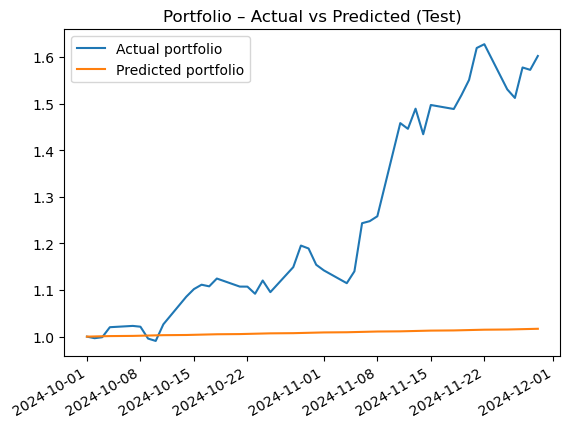

In [46]:
forecasts_best_weights = {
    "AMZN": amzn_results["pred_drift"],
    "NVDA": nvda_results["pred_drift"],
    "TLT":  tlt_results["pred_drift"],
    "QQQ":  qqq_results["pred_drift"],
    "BTC-USD": btc_usd_results["pred_drift"],
 }
portfolio_actual_best_wt, portfolio_pred_best_wt, rmse_port_best_wt = build_portfolio_forecast_normalised(
     forecasts, prices_test, best_w
 )

In [47]:
actual_ret_best_wt, pred_ret_best_wt = evaluate_5pct_goal(portfolio_actual_best_wt, portfolio_pred_best_wt)

Actual portfolio return (test):   60.20%
Model-implied return (test):      1.68%
❌ Model forecasts do NOT reach 5% return in test period.


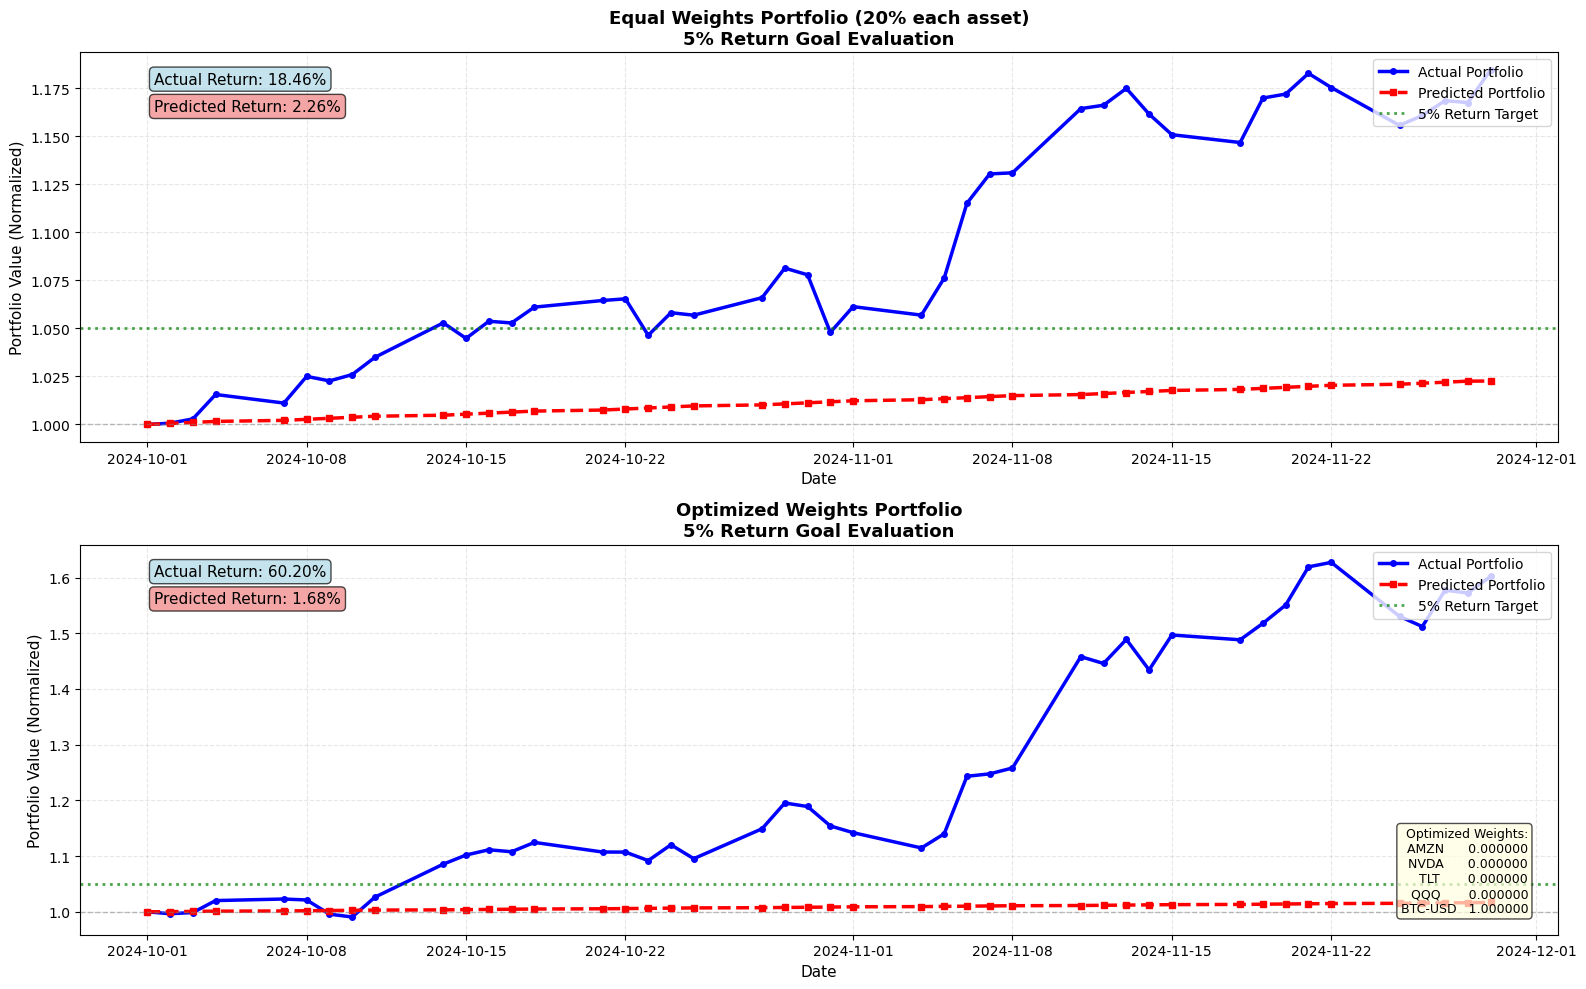

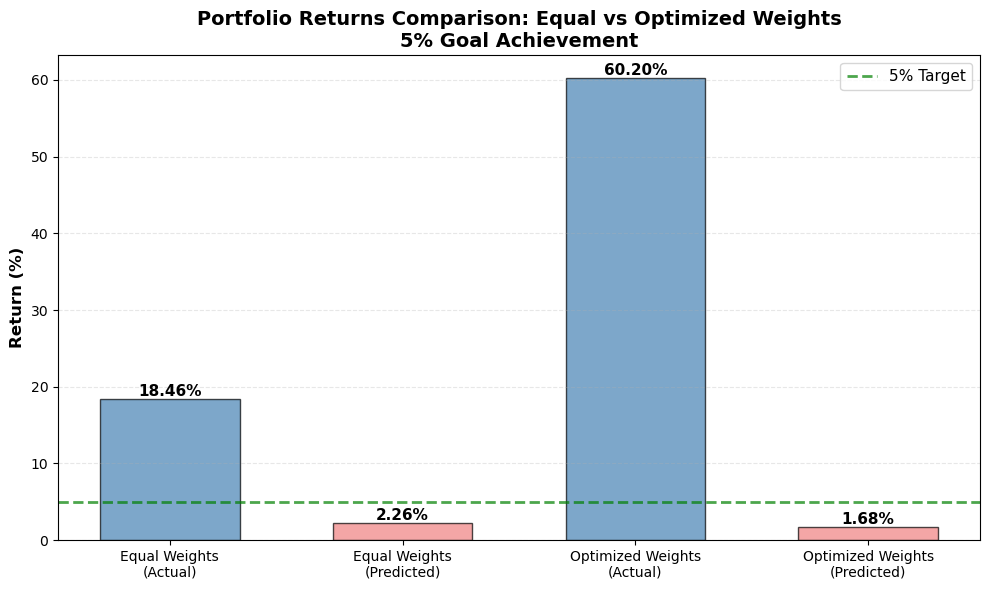

In [48]:
# Create visualization for 5% evaluation results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Left plot: Equal weights portfolio
ax1.plot(portfolio_actual.index, portfolio_actual, 
         label='Actual Portfolio', linewidth=2.5, color='blue', marker='o', markersize=4)
ax1.plot(portfolio_pred.index, portfolio_pred, 
         label='Predicted Portfolio', linewidth=2.5, color='red', linestyle='--', marker='s', markersize=4)
ax1.axhline(y=1.05, color='green', linestyle=':', linewidth=2, alpha=0.7, label='5% Return Target')
ax1.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add text annotations for returns
ax1.text(0.05, 0.95, f'Actual Return: {actual_ret*100:.2f}%', 
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax1.text(0.05, 0.88, f'Predicted Return: {pred_ret*100:.2f}%', 
         transform=ax1.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

ax1.set_title('Equal Weights Portfolio (20% each asset)\n5% Return Goal Evaluation', 
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Date', fontsize=11)
ax1.set_ylabel('Portfolio Value (Normalized)', fontsize=11)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Right plot: Optimized weights portfolio
ax2.plot(portfolio_actual_best_wt.index, portfolio_actual_best_wt, 
         label='Actual Portfolio', linewidth=2.5, color='blue', marker='o', markersize=4)
ax2.plot(portfolio_pred_best_wt.index, portfolio_pred_best_wt, 
         label='Predicted Portfolio', linewidth=2.5, color='red', linestyle='--', marker='s', markersize=4)
ax2.axhline(y=1.05, color='green', linestyle=':', linewidth=2, alpha=0.7, label='5% Return Target')
ax2.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add text annotations for returns
ax2.text(0.05, 0.95, f'Actual Return: {actual_ret_best_wt*100:.2f}%', 
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))
ax2.text(0.05, 0.88, f'Predicted Return: {pred_ret_best_wt*100:.2f}%', 
         transform=ax2.transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.7))

# Add weight information
weight_text = f"Optimized Weights:\n{best_w.to_string()}"
ax2.text(0.98, 0.05, weight_text, 
         transform=ax2.transAxes, fontsize=9, verticalalignment='bottom',
         horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

ax2.set_title('Optimized Weights Portfolio\n5% Return Goal Evaluation', 
              fontsize=13, fontweight='bold')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Portfolio Value (Normalized)', fontsize=11)
ax2.legend(loc='upper right', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Summary comparison bar chart
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Equal Weights\n(Actual)', 'Equal Weights\n(Predicted)', 
              'Optimized Weights\n(Actual)', 'Optimized Weights\n(Predicted)']
returns = [actual_ret*100, pred_ret*100, actual_ret_best_wt*100, pred_ret_best_wt*100]
colors = ['steelblue', 'lightcoral', 'steelblue', 'lightcoral']

bars = ax.bar(categories, returns, color=colors, edgecolor='black', alpha=0.7, width=0.6)

# Add 5% target line
ax.axhline(y=5, color='green', linestyle='--', linewidth=2, label='5% Target', alpha=0.7)

# Add value labels on bars
for bar, ret in zip(bars, returns):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{ret:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Return (%)', fontsize=12, fontweight='bold')
ax.set_title('Portfolio Returns Comparison: Equal vs Optimized Weights\n5% Goal Achievement', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')



plt.tight_layout()

plt.show()